In [1]:
import requests
import zipfile
import pathlib
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

/Users/kuroyami/neural_network_learning/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
root_dir = pathlib.Path("./data")
image_dir = root_dir / "pizza_steak_sushi"

In [3]:
if image_dir.is_dir():
    print("Already exists skipping...")
else:
    image_dir.mkdir(parents = True, exist_ok = True)

with open(root_dir / "content.zip", "wb") as dl:
    response = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    dl.write(response.content)

with zipfile.ZipFile(root_dir / "content.zip", "r") as zip_ref:
    zip_ref.extractall(image_dir)

Already exists skipping...


In [4]:
from PIL import Image

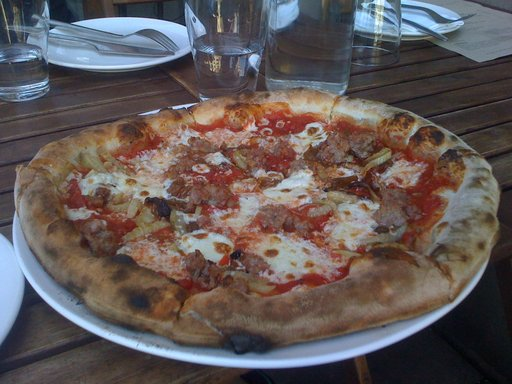

In [5]:
Image.open(image_dir / "train" / "pizza" / "5764.jpg")

In [6]:
def walk_thorugh_dir(dir_name):
    for root, dir, files in os.walk(dir_name):
     print(f"Root files: {root} | DirFiles: {dir} | Images: {len(files)}")

walk_thorugh_dir(image_dir)

Root files: data/pizza_steak_sushi | DirFiles: ['test', 'train'] | Images: 0
Root files: data/pizza_steak_sushi/test | DirFiles: ['steak', 'sushi', 'pizza'] | Images: 0
Root files: data/pizza_steak_sushi/test/steak | DirFiles: [] | Images: 19
Root files: data/pizza_steak_sushi/test/sushi | DirFiles: [] | Images: 31
Root files: data/pizza_steak_sushi/test/pizza | DirFiles: [] | Images: 25
Root files: data/pizza_steak_sushi/train | DirFiles: ['steak', 'sushi', 'pizza'] | Images: 0
Root files: data/pizza_steak_sushi/train/steak | DirFiles: [] | Images: 75
Root files: data/pizza_steak_sushi/train/sushi | DirFiles: [] | Images: 72
Root files: data/pizza_steak_sushi/train/pizza | DirFiles: [] | Images: 78


In [7]:
image_path_list = list(image_dir.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)

classes = random_image_path.parent.stem
# classes

img = Image.open(random_image_path)
# img

In [8]:
imgarray = np.asarray(img)
# imgarray

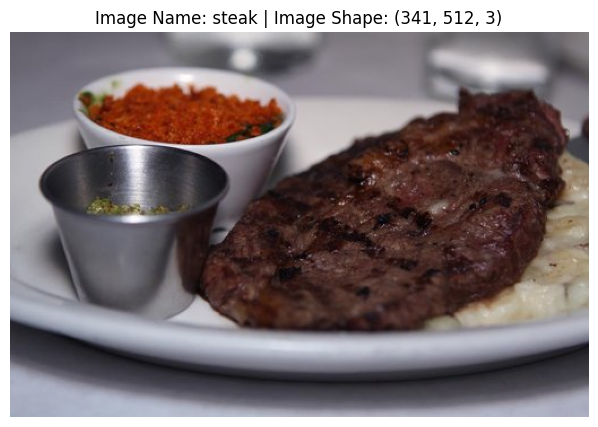

In [9]:
plt.figure(figsize = (10, 5))
plt.imshow(imgarray)
plt.title(f"Image Name: {str(classes)} | Image Shape: {imgarray.shape}")
# plt.inline(Flase)
plt.axis(False)
# plt.legend()
plt.show()

In [10]:
img_arrays = []

for img_path in image_path_list:
    # print(img_path)
    img = Image.open(img_path)
    img_array = np.asarray(img)
    img_class = img_path.parent.stem

    img_arrays.append((img_array, img_class))

In [11]:
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms.v2 as transforms

In [15]:
transform = transforms.Compose([
    transforms.Resize(size=[64, 64]),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale = True)
])

In [16]:
transformed_img = transform(img)

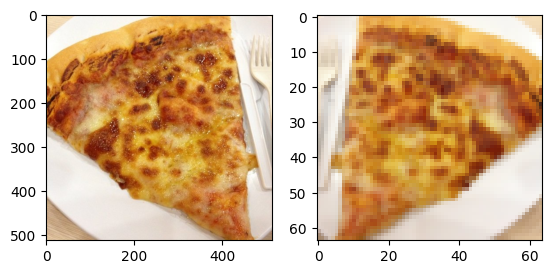

In [17]:
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.imshow(transformed_img.permute(1, 2, 0))

In [21]:
train_dir = image_dir / "train"
test_dir = image_dir / "test"

In [31]:
train_dataset =  datasets.ImageFolder(train_dir, transform = transform, target_transform = None)
test_dataset = datasets.ImageFolder(test_dir, transform = transform)

In [32]:
train_dataset, test_dataset

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                  Resize(size=[64, 64], interpolation=InterpolationMode.BILINEAR, antialias=True)
                  RandomHorizontalFlip(p=0.5)
                  ToImage()
                  ToDtype(scale=True)
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                  Resize(size=[64, 64], interpolation=InterpolationMode.BILINEAR, antialias=True)
                  RandomHorizontalFlip(p=0.5)
                  ToImage()
                  ToDtype(scale=True)
            ))

In [33]:
classes = train_dataset.classes
classes

['pizza', 'steak', 'sushi']

In [34]:
test_dataset.classes

['pizza', 'steak', 'sushi']

In [35]:
train_dataset.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [36]:
train_loader = DataLoader(train_dataset,
                         shuffle = True,
                         batch_size = 32)

test_loader = DataLoader(test_dataset,
                        shuffle = False,
                        batch_size = 32)

In [38]:
image, target = next(iter(train_loader))

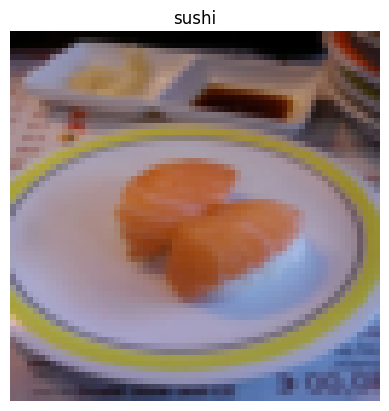

In [54]:
plt.imshow(image[0].permute(1, 2, 0))
plt.title(classes[target[0]])
plt.axis(False)
plt.show()